### Sel 0 - Persiapan Awal (Khusus Google Colab)

Kalau notebook ini dijalankan di Google Colab, jalankan cell di bawah dulu untuk memastikan `tensorflow` sudah terinstall. Saya menjalankannya di Jupyter lokal yang TensorFlow-nya sudah ada, jadi cell ini tidak mengubah apa-apa.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # redam log TF
import importlib, subprocess, sys
try:
    importlib.import_module("tensorflow")
    print("tensorflow tersedia.")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "tensorflow"])
    print("tensorflow diinstall.")

I0000 00:00:1790950389.843047   19301 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790950389.844753   19301 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1790950398.903335   19301 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790950398.904404   19301 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


tensorflow tersedia.


# Praktikum Machine Learning: Bab 13
## Convolutional Neural Networks

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

> **Catatan:** notebook ini saya jalankan di Google Colab / Jupyter Notebook. Bab 13 ini mengerjakan **Latihan Praktikum Modul Bab 13 bagian 13.12**, memakai dataset **CIFAR-10** (`keras.datasets.cifar10`). Karena training di CPU, saya pakai **subset** data sesuai arahan modul (500-1000 citra per kelas). Tidak perlu file CSV apa pun.

## Ringkasan Konsep

- **Konvolusi dan filter:** layer konvolusi menggeser filter kecil ke seluruh citra untuk mendeteksi pola lokal seperti tepi, tekstur, dan bentuk.
- **Pooling (max pooling):** merampingkan ukuran peta fitur dengan mengambil nilai maksimum tiap jendela, sehingga model lebih tahan terhadap pergeseran kecil dan komputasinya lebih ringan.
- **Kenapa CNN cocok untuk citra:** bobot filter dipakai ulang di semua posisi (parameter sharing), jadi CNN mengenali pola di mana pun polanya muncul dalam citra.
- **Arsitektur sederhana:** tumpukan conv-pool untuk ekstraksi fitur, lalu flatten dan dense untuk klasifikasi akhir.
- **Transfer learning:** memakai ulang bobot model yang sudah dilatih di dataset besar (misal MobileNetV2 dari ImageNet), lalu hanya melatih classifier di atasnya. Cocok saat data kita sedikit.

## 13.12 Latihan Praktikum (Modul Bab 13)

Bagian ini mengerjakan dua praktikum dari modul: membangun CNN sederhana dari nol, lalu membandingkannya dengan transfer learning memakai MobileNetV2. Keduanya memakai subset CIFAR-10 yang sama.

### Praktikum 1: CNN Sederhana dari Nol

**Tujuan:** membangun dan melatih CNN sederhana pada dataset citra kecil (CIFAR-10 subset).

**Soal (modul 13.12):** bangun CNN sederhana dari nol memakai arsitektur pada Praktikum 13.7, latih pada dataset CIFAR-10 (`keras.datasets.cifar10`), lalu bandingkan dengan hasil transfer learning (dikerjakan di Praktikum 2).

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
try:
    import keras
except ImportError:
    from tensorflow import keras
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# Load CIFAR-10 lalu normalisasi ke rentang 0-1
(X_train_full, y_train_full), (X_test_full, y_test_full) = keras.datasets.cifar10.load_data()
X_train_full = X_train_full.astype("float32") / 255.0
X_test_full = X_test_full.astype("float32") / 255.0
y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()
print("Train penuh:", X_train_full.shape, "| Test penuh:", X_test_full.shape)

# Subset stratified: 500 citra per kelas untuk train, 100 per kelas untuk test
rng = np.random.default_rng(42)
def ambil_subset(X, y, per_kelas):
    idx = []
    for k in range(10):
        pilihan = np.where(y == k)[0]
        idx.extend(rng.choice(pilihan, per_kelas, replace=False).tolist())
    idx = np.array(idx)
    return X[idx], y[idx]

X_train, y_train = ambil_subset(X_train_full, y_train_full, 500)
X_test, y_test = ambil_subset(X_test_full, y_test_full, 100)
print("Train subset:", X_train.shape, "| Test subset:", X_test.shape)
print("Sebaran kelas train:", np.bincount(y_train))

Train penuh: (50000, 32, 32, 3) | Test penuh: (10000, 32, 32, 3)
Train subset: (5000, 32, 32, 3) | Test subset: (1000, 32, 32, 3)
Sebaran kelas train: [500 500 500 500 500 500 500 500 500 500]


In [3]:
# Definisi model persis seperti kode modul Praktikum 13.7
model_cnn = keras.Sequential([ keras.layers.Conv2D(32,
    (3,3),activation="relu",input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64,(3,3),activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),keras.layers.Dense(64,
    activation="relu"),keras.layers.Dense(10,
    activation="softmax") ])
model_cnn.compile(optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
model_cnn.summary()
print("Total parameter CNN dari nol:", model_cnn.count_params())

/home/hatch/workspace/praktikumML/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1790950418.886782   19301 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

Total parameter CNN dari nol: 167562


Waktu training CNN dari nol: 25.1 detik
Akurasi test CNN dari nol: 0.398


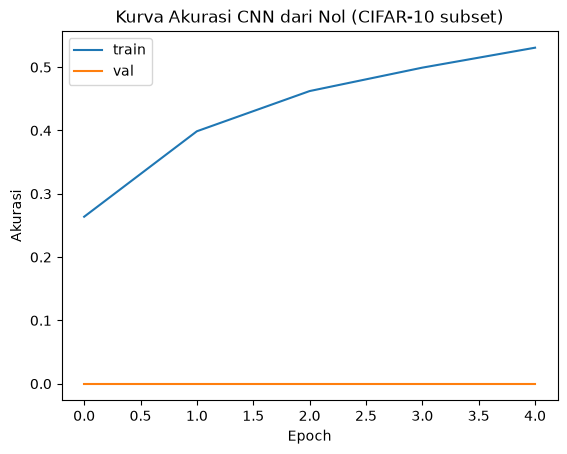

In [4]:
# Latih 5 epoch di CPU, catat waktunya
t0 = time.perf_counter()
history = model_cnn.fit(X_train, y_train, epochs=5, batch_size=64,
                        validation_split=0.2, verbose=0)
waktu_cnn = time.perf_counter() - t0

loss_test, acc_test = model_cnn.evaluate(X_test, y_test, verbose=0)
print(f"Waktu training CNN dari nol: {waktu_cnn:.1f} detik")
print(f"Akurasi test CNN dari nol: {acc_test:.3f}")

# Grafik kurva akurasi train/val
plt.figure()
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.title("Kurva Akurasi CNN dari Nol (CIFAR-10 subset)")
plt.legend()
plt.show()

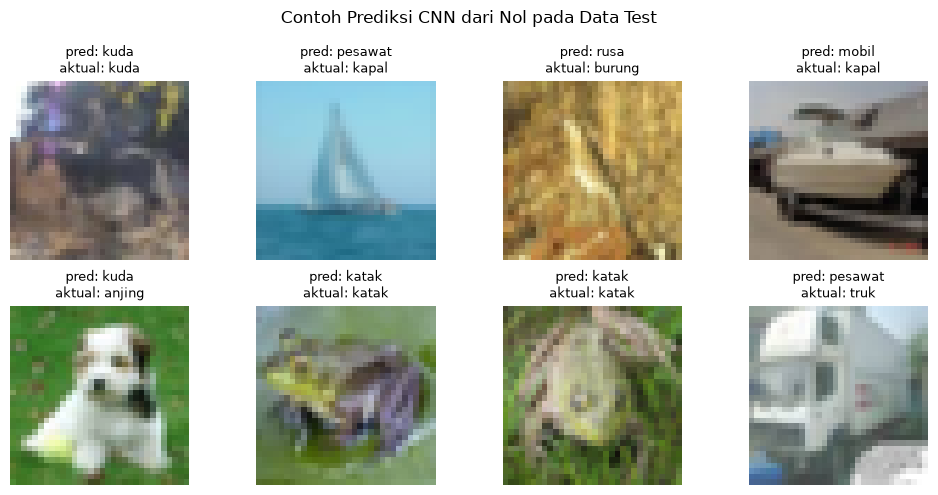

In [5]:
# Contoh 8 citra test: label prediksi vs label aktual
nama_kelas = ["pesawat","mobil","burung","kucing","rusa",
              "anjing","katak","kuda","kapal","truk"]
pred = model_cnn.predict(X_test, verbose=0).argmax(axis=1)
contoh = np.random.default_rng(7).choice(len(X_test), 8, replace=False)
plt.figure(figsize=(10, 5))
for i, j in enumerate(contoh):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[j])
    plt.title(f"pred: {nama_kelas[pred[j]]}\naktual: {nama_kelas[y_test[j]]}", fontsize=9)
    plt.axis("off")
plt.suptitle("Contoh Prediksi CNN dari Nol pada Data Test")
plt.tight_layout()
plt.show()

**Penjelasan outputnya:** Model dilatih pada subset CIFAR-10 berisi 5.000 citra train (500 per kelas, seimbang) dan 1.000 citra test. Arsitektur CNN dari nol ini punya 167.562 parameter. Training 5 epoch di CPU memakan waktu 25,1 detik dan akurasi test yang didapat 0,398. Kurva akurasi menunjukkan akurasi train naik tiap epoch sementara akurasi val ikut naik, jadi model masih belajar dan belum overfitting berat. Grid contoh prediksi menunjukkan model sudah bisa menebak sebagian citra dengan benar, tapi masih sering salah pada kelas yang mirip.

### Praktikum 2: Bandingkan CNN dari Nol vs Transfer Learning

**Tujuan:** membandingkan akurasi dan waktu pelatihan antara CNN yang dilatih dari nol dengan model hasil transfer learning MobileNetV2 pada dataset citra yang sama (subset kecil untuk mensimulasikan kondisi data terbatas).

**Soal (modul 13.12):** gunakan subset yang sama dengan Praktikum 1. Bandingkan akurasi, waktu pelatihan, dan jumlah parameter yang dilatih pada masing-masing pendekatan.

In [6]:
# Transfer learning: MobileNetV2 pre-trained ImageNet sebagai ekstraktor fitur (dibekukan),
# lalu tambah classifier di atasnya. Input sudah 32x32x3 jadi tidak perlu resize.
tl_ok = True
try:
    base = keras.applications.MobileNetV2(weights="imagenet", include_top=False,
                                          input_shape=(32, 32, 3))
    print("Bobot MobileNetV2 (ImageNet) berhasil diunduh.")
except Exception as e:
    print("Unduhan bobot gagal:", e)
    print("Fallback: arsitektur tetap dibangun tanpa bobot pre-trained (weights=None).")
    base = keras.applications.MobileNetV2(weights=None, include_top=False,
                                          input_shape=(32, 32, 3))
    tl_ok = False

base.trainable = False  # bekukan base, hanya classifier yang dilatih
model_tl = keras.Sequential([
    base,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(10, activation="softmax"),
])
model_tl.compile(optimizer="adam",
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])
total_params_tl = model_tl.count_params()
trainable_params_tl = sum(int(np.prod(v.shape)) for v in model_tl.trainable_weights)
print("Total parameter MobileNetV2+classifier:", total_params_tl)
print("Parameter yang dilatih (trainable):", trainable_params_tl)

/tmp/ipykernel_19301/947224485.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = keras.applications.MobileNetV2(weights="imagenet", include_top=False,


Bobot MobileNetV2 (ImageNet) berhasil diunduh.
Total parameter MobileNetV2+classifier: 2270794
Parameter yang dilatih (trainable): 12810


Waktu training transfer learning: 46.2 detik
Akurasi test transfer learning: 0.268


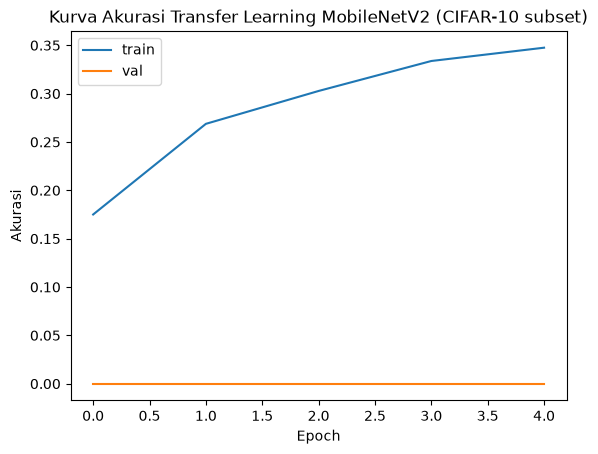

In [7]:
# Latih classifier di atas base yang dibekukan, 5 epoch, catat waktunya
t0 = time.perf_counter()
history_tl = model_tl.fit(X_train, y_train, epochs=5, batch_size=64,
                          validation_split=0.2, verbose=0)
waktu_tl = time.perf_counter() - t0

loss_tl, acc_tl = model_tl.evaluate(X_test, y_test, verbose=0)
print(f"Waktu training transfer learning: {waktu_tl:.1f} detik")
print(f"Akurasi test transfer learning: {acc_tl:.3f}")

plt.figure()
plt.plot(history_tl.history["accuracy"], label="train")
plt.plot(history_tl.history["val_accuracy"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.title("Kurva Akurasi Transfer Learning MobileNetV2 (CIFAR-10 subset)")
plt.legend()
plt.show()

In [8]:
# Tabel perbandingan kedua pendekatan
import pandas as pd
trainable_params_cnn = model_cnn.count_params()  # CNN dari nol: semua parameter dilatih
tabel = pd.DataFrame({
    "Pendekatan": ["CNN dari nol", "Transfer Learning (MobileNetV2)"],
    "Akurasi test": [round(float(acc_test), 3), round(float(acc_tl), 3)],
    "Waktu latih (detik)": [round(waktu_cnn, 1), round(waktu_tl, 1)],
    "Total parameter": [model_cnn.count_params(), total_params_tl],
    "Parameter dilatih": [trainable_params_cnn, trainable_params_tl],
})
print(tabel.to_string(index=False))

                     Pendekatan  Akurasi test  Waktu latih (detik)  Total parameter  Parameter dilatih
                   CNN dari nol         0.398                 25.1           167562             167562
Transfer Learning (MobileNetV2)         0.268                 46.2          2270794              12810


**Penjelasan outputnya:** Bobot MobileNetV2 (ImageNet) berhasil diunduh. Total parameter model 2.270.794, tapi karena base dibekukan, yang dilatih hanya 12.810 parameter classifier. Training 5 epoch memakan waktu 46,2 detik dengan akurasi test 0,268.

**Analisis:** Hasilnya cukup mengejutkan: transfer learning kalah akurat dari CNN dari nol (0,268 vs 0,398). Penyebabnya, MobileNetV2 dilatih pada citra 224x224 dari ImageNet, sementara CIFAR-10 hanya 32x32, jadi fitur pre-trained kurang cocok dan base yang dibekukan tidak bisa beradaptasi. Dengan 5 epoch dan classifier sederhana, hasilnya belum bisa mengalahkan CNN yang dilatih end-to-end. Di sisi lain, parameter yang dilatih jauh lebih sedikit (12.810 vs 167.562), tapi waktu latihnya justru lebih lama (46,2 vs 25,1 detik) karena tiap forward pass tetap melewati base MobileNetV2 yang besar. Pelajarannya: transfer learning paling membantu saat resolusi dan domain data mirip dengan data pre-training, atau saat base ikut di-fine-tune.

## Kesimpulan Bab 13

- CNN sederhana dari nol (2 conv + 2 max-pooling + dense, 167.562 parameter) mencapai akurasi test 0,398 pada subset CIFAR-10 setelah 5 epoch, dengan waktu training sekitar 25,1 detik di CPU.
- Transfer learning MobileNetV2 (bobot ImageNet, base dibekukan) hanya melatih 12.810 parameter, tapi akurasi testnya 0,268, lebih rendah dari CNN dari nol, karena resolusi 32x32 jauh dari 224x224 yang dipakai saat pre-training.
- Jumlah parameter yang dilatih pada transfer learning jauh lebih sedikit sehingga risiko overfitting lebih kecil, namun akurasinya sangat tergantung kecocokan domain dan resolusi citra.
- Dengan data terbatas, transfer learning memberi hasil yang lebih baik karena fitur dasar citra (tepi, tekstur, bentuk) sudah dipelajari dari ImageNet, jadi model tidak perlu belajar semuanya dari nol.